# Portfolio Backtests: RL Agent vs Baseline Strategies

Compare trained RL agent performance against baseline strategies on test data.

**All parameters loaded from `config.py`**

## 1. Setup & Imports

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import json
import warnings
from typing import Dict, List

import matplotlib.pyplot as plt
import seaborn as sns

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Import config and RL system
from config import *
from rl_system import (
    PortfolioEnv, PortfolioMonitor,
    backtest_rl_agent, backtest_baseline,
    EqualWeight, BuyHold, RiskParity, Momentum, MinVariance
)

# Plotting setup
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

%matplotlib inline

print("✓ All imports successful")

✓ All imports successful


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## 2. Configuration

In [2]:
# Setup output directory
OUTPUT_DIR_BACKTEST = PROJECT_ROOT / 'results' / 'backtests'
OUTPUT_DIR_BACKTEST.mkdir(parents=True, exist_ok=True)

# Print configuration from config.py
print(f"{'='*80}")
print("BACKTEST CONFIGURATION")
print(f"{'='*80}")
print(f"\n📊 Test data: {TEST_PATH}")
print(f"📁 Models: {OUTPUT_DIR}")
print(f"💾 Results: {OUTPUT_DIR_BACKTEST}")
print(f"\n🎯 Parameters:")
print(f"   Reward type:      {REWARD_TYPE}")
print(f"   Reward lookback:  {REWARD_LOOKBACK}")
print(f"   Initial capital:  ${INITIAL_CAPITAL:,.0f}")
print(f"   Transaction cost: {TRANSACTION_COST*10000:.1f} bps")
print(f"   Max weight:       {MAX_WEIGHT_PER_ASSET:.0%}")
print(f"   Rebalance freq:   {REBALANCE_FREQUENCY} weeks")
print(f"{'='*80}")

BACKTEST CONFIGURATION

📊 Test data: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/data/processed/test.parquet
📁 Models: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/models
💾 Results: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/results/backtests

🎯 Parameters:
   Reward type:      multi_component
   Reward lookback:  12
   Initial capital:  $100,000
   Transaction cost: 25.0 bps
   Max weight:       40%
   Rebalance freq:   4 weeks


## 3. Load Data & Metadata

In [3]:
# Load test data
print(f"\n📂 Loading test data...")
test_data = pd.read_parquet(TEST_PATH)
test_data[DATE_COL] = pd.to_datetime(test_data[DATE_COL])

print(f"  ✓ Loaded {len(test_data):,} samples")
print(f"  Date range: {test_data[DATE_COL].min().date()} to {test_data[DATE_COL].max().date()}")
print(f"  Periods: {test_data[DATE_COL].nunique()}")
print(f"  Tickers: {TICKERS}")
print(f"  Features: {len(FEATURE_COLS)}")



📂 Loading test data...
  ✓ Loaded 427 samples
  Date range: 2024-09-04 to 2025-10-29
  Periods: 61
  Tickers: ['NVDA', 'MU', 'AAPL', 'AMD', 'ASML', 'MSFT', 'GOOG']
  Features: 149


## 4. Load Trained Model

In [4]:
# Load best model
print(f"\nLoading trained model...")
fold_results_path = OUTPUT_DIR / 'fold_results.csv'

rl_model = None
if fold_results_path.exists():
    fold_results = pd.read_csv(fold_results_path)
    
    # Select best model
    best_idx = fold_results['best_val_sharpe'].idxmax()
    best_fold = int(fold_results.loc[best_idx, 'fold'])
    best_sharpe = fold_results.loc[best_idx, 'best_val_sharpe']
    
    print(f"  Selected: Pre-Trained Model from Fold {best_fold} (Val Sharpe: {best_sharpe:.3f})")
    
    # Display fold results
    print("\nFolds Results from Training/Validation:")
    display(fold_results[['fold', 'best_val_sharpe', 'sharpe_ratio', 'total_return']])
    
    model_path = OUTPUT_DIR / f"fold_{best_fold}" / "best_model.zip"
    
    if model_path.exists():
        rl_model = PPO.load(model_path)
        print(f"  ✓ Model loaded: {model_path}")
    else:
        print(f"  ⚠️  Model not found: {model_path}")
else:
    print(f"  ⚠️  Fold results not found: {fold_results_path}")
    print("  Run training first")


Loading trained model...
  Selected: Pre-Trained Model from Fold 2 (Val Sharpe: 1.036)

Folds Results from Training/Validation:


,fold,best_val_sharpe,sharpe_ratio,total_return
0,0,0.973106,0.798108,0.302016
1,1,0.145875,0.143330,0.077583
2,2,1.036263,0.557191,0.232623


  ✓ Model loaded: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/models/fold_2/best_model.zip


## 7. Run Backtests

In [9]:
# Run backtests
print(f"\n{'='*80}")
print("RUNNING BACKTESTS")
print(f"{'='*80}\n")

results = {}
errors = []

# 1. RL Agent Backtest
print("1. RL Agent Backtest")
print("-" * 80)
if rl_model is not None:
    try:
        rl_result = backtest_rl_agent(
            model=rl_model,
            data=test_data,
            feature_cols=FEATURE_COLS,
            tickers=TICKERS,
            rebalance_frequency=REBALANCE_FREQUENCY,
            transaction_cost=TRANSACTION_COST,
            max_weight_per_asset=MAX_WEIGHT_PER_ASSET,
            reward_lookback=REWARD_LOOKBACK,
            initial_capital=INITIAL_CAPITAL,
            reward_type=REWARD_TYPE,
            seed=RANDOM_SEED
        )
        results['RL Agent'] = rl_result
        print(f"  ✓ RL Agent backtest completed successfully")
        print(f"    Final value: ${rl_result['stats']['portfolio_value']:,.2f}")
        print(f"    Sharpe ratio: {rl_result['stats']['sharpe_ratio']:.3f}")
    except Exception as e:
        error_msg = f"RL Agent backtest failed: {str(e)}"
        errors.append(error_msg)
        print(f"  ✗ {error_msg}")
        import traceback
        traceback.print_exc()
else:
    error_msg = "RL model not loaded"
    errors.append(error_msg)
    print(f"  ✗ {error_msg}")

print()

# 2. Baseline Strategies Backtest
print("2. Baseline Strategies Backtest")
print("-" * 80)

strategies = [
    EqualWeight(TICKERS, MAX_WEIGHT_PER_ASSET),
    BuyHold(TICKERS, MAX_WEIGHT_PER_ASSET),
    RiskParity(TICKERS, MAX_WEIGHT_PER_ASSET, DATE_COL, REWARD_LOOKBACK),
    Momentum(TICKERS, MAX_WEIGHT_PER_ASSET, DATE_COL, REWARD_LOOKBACK),
    MinVariance(TICKERS, MAX_WEIGHT_PER_ASSET, DATE_COL, REWARD_LOOKBACK)
]

for strategy in strategies:
    try:
        result = backtest_baseline(
            strategy=strategy,
            data=test_data,
            date_col=DATE_COL,
            tickers=TICKERS,
            rebalance_frequency=REBALANCE_FREQUENCY,
            transaction_cost=TRANSACTION_COST,
            initial_capital=INITIAL_CAPITAL
        )
        results[strategy.name] = result
        print(f"  ✓ {strategy.name:20s} | Sharpe: {result['stats']['sharpe_ratio']:6.3f} | Return: {result['stats']['total_return']:7.2%}")
    except Exception as e:
        error_msg = f"{strategy.name} failed: {str(e)}"
        errors.append(error_msg)
        print(f"  ✗ {error_msg}")

print()
print(f"{'='*80}")
print(f"BACKTESTS COMPLETE: {len(results)}/{len(strategies) + 1} strategies successful")
if errors:
    print(f"Errors: {len(errors)}")
    for err in errors:
        print(f"  - {err}")
print(f"{'='*80}\n")

# Create performance summary
print("Generating performance summary...")
summary = []

for name, result in results.items():
    stats = result['stats']
    traj = result['trajectory']

    # Calculate turnover
    if len(traj['weights']) > 1:
        weights_array = np.array(traj['weights'])
        turnover = np.abs(np.diff(weights_array, axis=0)).sum(axis=1).mean()
    else:
        turnover = 0.0

    # Calculate win rate
    returns = np.array(traj['returns'])
    win_rate = (returns > 0).sum() / len(returns) if len(returns) > 0 else 0.0

    summary.append({
        'Strategy': name,
        'Total Return': stats['total_return'],
        'Sharpe Ratio': stats['sharpe_ratio'],
        'Volatility': stats['volatility'],
        'Max Drawdown': stats['max_drawdown'],
        'Final Value': stats['portfolio_value'],
        'Avg Turnover': turnover,
        'Win Rate': win_rate
    })

summary_df = pd.DataFrame(summary)

# Sort by Sharpe ratio (descending)
summary_df = summary_df.sort_values('Sharpe Ratio', ascending=False).reset_index(drop=True)

# Display summary
print(f"\n{'='*80}")
print("PERFORMANCE SUMMARY")
print(f"{'='*80}\n")

display(summary_df.round(4))

# Save summary
summary_df.to_csv(OUTPUT_DIR_BACKTEST / 'backtest_summary.csv', index=False)
print(f"\n✓ Summary saved: {OUTPUT_DIR_BACKTEST / 'backtest_summary.csv'}")


RUNNING BACKTESTS

1. RL Agent Backtest
--------------------------------------------------------------------------------
  ✓ RL Agent backtest completed successfully
    Final value: $130,195.26
    Sharpe ratio: 0.645

2. Baseline Strategies Backtest
--------------------------------------------------------------------------------
  ✓ Equal Weight         | Sharpe:  1.344 | Return:  67.11%
  ✓ Buy & Hold           | Sharpe:  1.275 | Return:  62.11%
  ✓ Risk Parity          | Sharpe:  1.344 | Return:  67.11%
  ✓ Momentum             | Sharpe:  1.326 | Return:  62.73%
  ✓ Min Variance         | Sharpe:  1.301 | Return:  57.99%

BACKTESTS COMPLETE: 6/6 strategies successful

Generating performance summary...

PERFORMANCE SUMMARY



,Strategy,Total Return,Sharpe Ratio,Volatility,Max Drawdown,Final Value,Avg Turnover,Win Rate
0,Risk Parity,0.6711,1.3445,0.3282,-0.2965,167110.4229,0.0000,0.6500
1,Equal Weight,0.6711,1.3445,0.3282,-0.2965,167110.4229,0.0000,0.6500
2,Momentum,0.6273,1.3263,0.3155,-0.2958,162731.7851,0.0954,0.5667
3,Min Variance,0.5799,1.3014,0.3020,-0.2908,157985.4630,0.0963,0.6000
4,Buy & Hold,0.6211,1.2748,0.3257,-0.3126,162110.8298,0.0334,0.6333
5,RL Agent,0.3020,0.6449,0.3516,-0.3554,130195.2611,0.2575,0.5932



✓ Summary saved: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/results/backtests/backtest_summary.csv


## 9. Visualization: Cumulative Returns

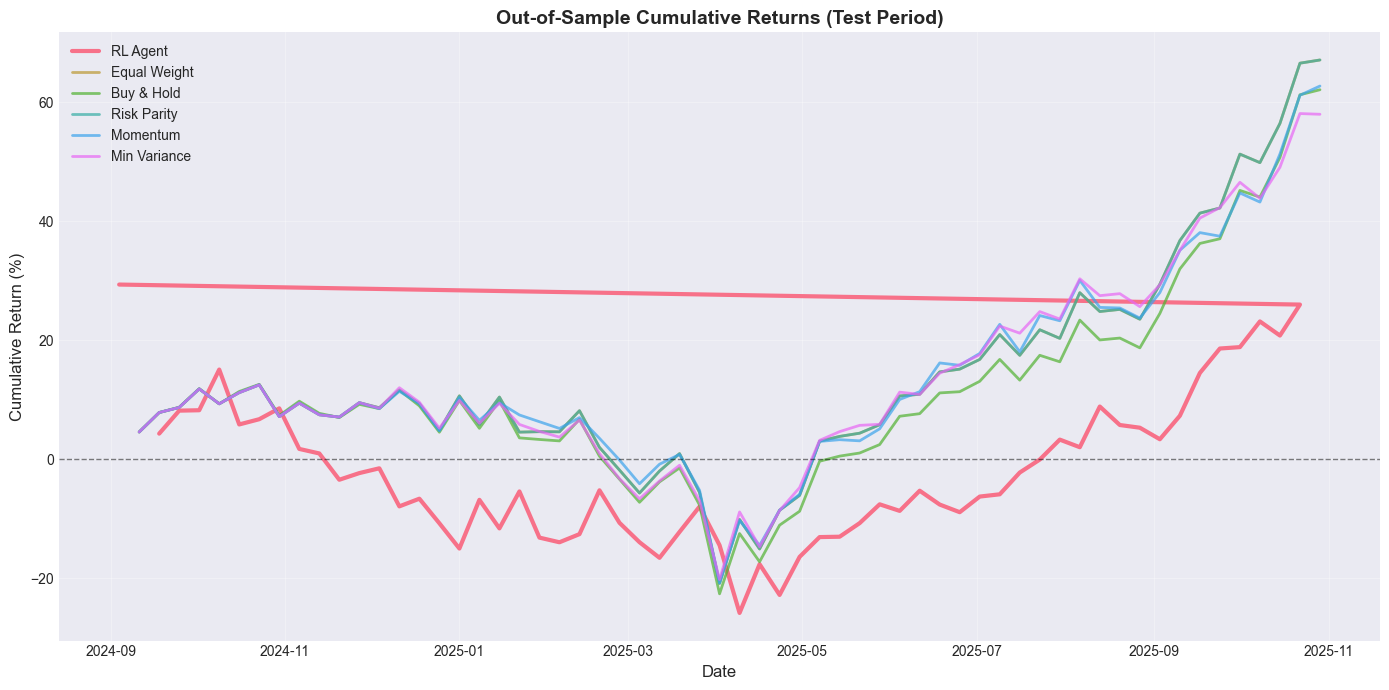

✓ Plot saved: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/results/backtests/cumulative_returns.png


In [10]:
fig, ax = plt.subplots(figsize=(14, 7))

for name, result in results.items():
    returns = np.array(result['trajectory']['returns'])
    dates = result['trajectory']['dates'][1:]  # Skip first (no return yet)
    
    cum_returns = (np.exp(np.cumsum(returns)) - 1) * 100
    
    linewidth = 3 if name == 'RL Agent' else 2
    alpha = 1.0 if name == 'RL Agent' else 0.7
    
    ax.plot(dates, cum_returns, label=name, linewidth=linewidth, alpha=alpha)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Return (%)', fontsize=12)
ax.set_title('Out-of-Sample Cumulative Returns (Test Period)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.savefig(OUTPUT_DIR_BACKTEST / 'cumulative_returns.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Plot saved: {OUTPUT_DIR_BACKTEST / 'cumulative_returns.png'}")

## 10. Visualization: RL Agent Portfolio Weights

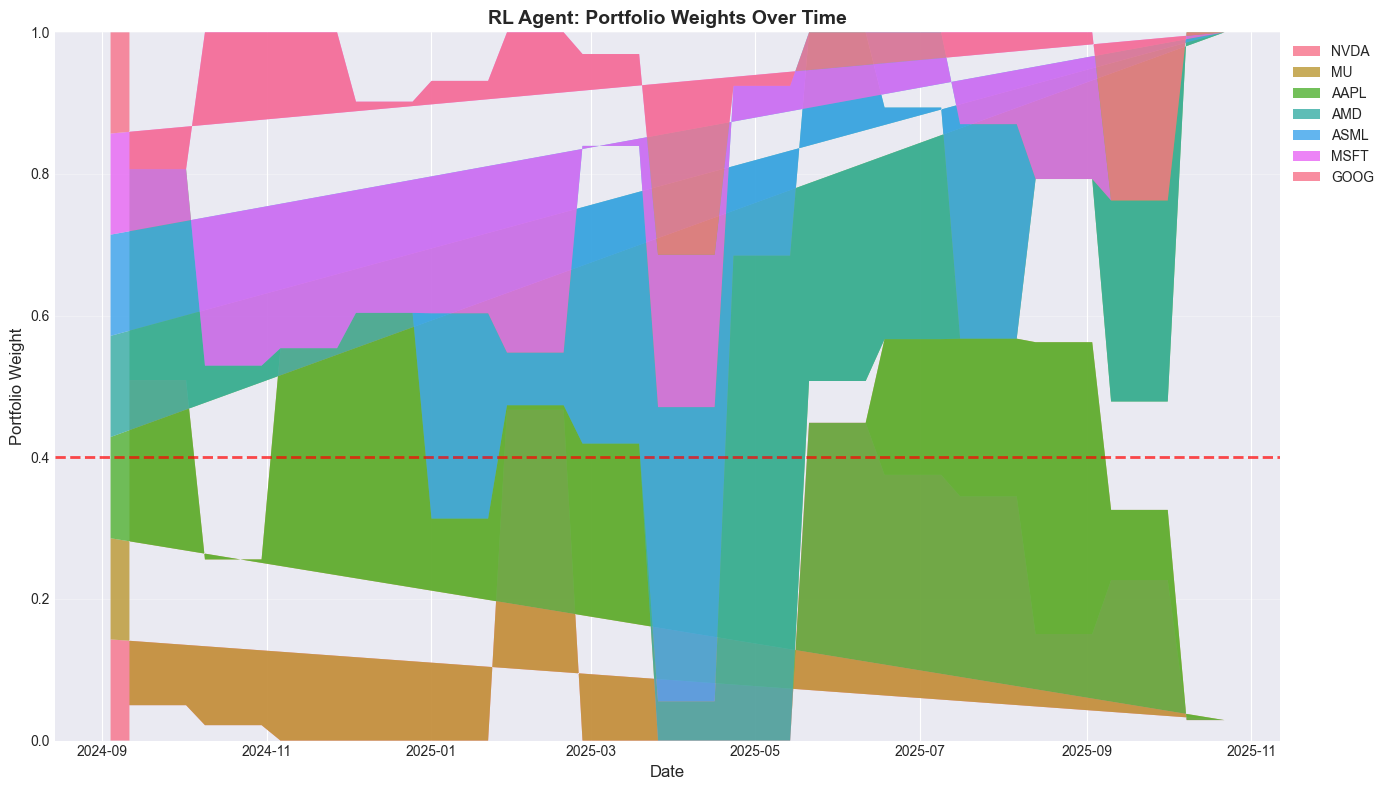

✓ Plot saved: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/results/backtests/rl_weights_evolution.png

Average Portfolio Weights:
  NVDA: 14.3%
  MU: 23.7%
  AAPL: 11.9%
  AMD: 12.5%
  ASML: 12.6%
  MSFT: 18.1%
  GOOG: 7.0%


In [7]:
if 'RL Agent' in results:
    rl_trajectory = results['RL Agent']['trajectory']
    weights = np.array(rl_trajectory['weights'])
    dates = rl_trajectory['dates']
    
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Stacked area chart
    ax.stackplot(dates, weights.T, labels=TICKERS, alpha=0.8)
    
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Portfolio Weight', fontsize=12)
    ax.set_title('RL Agent: Portfolio Weights Over Time', fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add constraint line
    ax.axhline(y=MAX_WEIGHT_PER_ASSET, color='red', linestyle='--', 
               linewidth=2, label=f'Max Weight ({MAX_WEIGHT_PER_ASSET:.0%})', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR_BACKTEST / 'rl_weights_evolution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Plot saved: {OUTPUT_DIR_BACKTEST / 'rl_weights_evolution.png'}")
    
    # Print average weights
    avg_weights = weights.mean(axis=0)
    print("\nAverage Portfolio Weights:")
    for ticker, weight in zip(TICKERS, avg_weights):
        print(f"  {ticker}: {weight:.1%}")
else:
    print("⚠️  RL Agent results not available")

## 11. Save Trajectories

In [8]:
# Save trajectories
print("💾 Saving trajectories...")

for name, result in results.items():
    traj = result['trajectory']

    df = pd.DataFrame({
        'date': traj['dates'][1:],
        'return': traj['returns'],
        'value': traj['values'][1:]
    })

    weights_df = pd.DataFrame(
        traj['weights'][1:],
        columns=[f'weight_{ticker}' for ticker in TICKERS]
    )

    df = pd.concat([df, weights_df], axis=1)

    safe_name = name.replace(' ', '_').replace('&', 'and').lower()
    df.to_csv(OUTPUT_DIR_BACKTEST / f'trajectory_{safe_name}.csv', index=False)
    print(f"  ✓ {name}: trajectory_{safe_name}.csv")

print(f"\n{'='*80}")
print(f"✓ ALL RESULTS SAVED TO: {OUTPUT_DIR_BACKTEST}")
print(f"{'='*80}")

💾 Saving trajectories...
  ✓ RL Agent: trajectory_rl_agent.csv
  ✓ Equal Weight: trajectory_equal_weight.csv
  ✓ Buy & Hold: trajectory_buy_and_hold.csv
  ✓ Risk Parity: trajectory_risk_parity.csv
  ✓ Momentum: trajectory_momentum.csv
  ✓ Min Variance: trajectory_min_variance.csv

✓ ALL RESULTS SAVED TO: /Users/nataliamarko/Documents/GitHub_Projects/reinforcement_learning_in_finance/rl_relabalance_portfolio/results/backtests
